In [1]:
import json
from dataclasses import dataclass
from typing import Literal

import numpy as np

from constants import LC_VALLEY_BATTERY_ARC as ARCS
from constants import LC_VALLEY_BATTERY_BUILDING as BUILDING_NAMES
from constants import LC_VALLEY_BATTERY_CONVEYOR as CONVEYORS
from constants import LC_VALLEY_BATTERY_XY as DIMS

type Direction = Literal["NORTH"] | Literal["EAST"] | Literal["SOUTH"] | Literal["WEST"]
type Resource = str


@dataclass
class Solution:
    building_x: list[int]
    building_y: list[int]
    building_orientation: list[Direction]
    building_dx: list[int]
    building_dy: list[int]
    flow: list[list[int]]
    flow_choice: list[Resource]
    conveyor_start_x: list[int]
    conveyor_start_y: list[int]
    conveyor_end_x: list[int]
    conveyor_end_y: list[int]
    pickup_perm: list[int]
    max_x: int


with open("output_flow.json") as f:
    data = json.load(f)
    data["building_orientation"] = [x["e"] for x in data["building_orientation"]]
    data["flow_choice"] = [x if x is None else x["e"] for x in data["flow_choice"]]
    data = Solution(**data)

flow = np.array(data.flow)


def trace_path(arcs, f):
    select = arcs[f != 0]
    rev = select[:, ::-1]
    edges = np.where(f[f != 0][:, None] == 1, select, rev)
    starts = edges[edges[:, 0] == 2 * DIMS[0] * DIMS[1] + 1, 1]
    paths = []
    for start in starts:
        path = [start.item()]
        pos = start
        while pos != 2 * DIMS[0] * DIMS[1] + 2:
            pos = edges[edges[:, 0] == pos, 1].item()
            path.append(pos)
        path.pop()  # get rid of the sink node
        paths.append(path)
    X, Y = DIMS
    paths = [[p % (X * Y) for p in path] for path in paths]
    paths = [[(p % X, p // X + 1) for p in path] for path in paths]
    paths = [
        [path[0]] + [b for a, b in zip(path, path[1:]) if a != b] for path in paths
    ]

    return paths

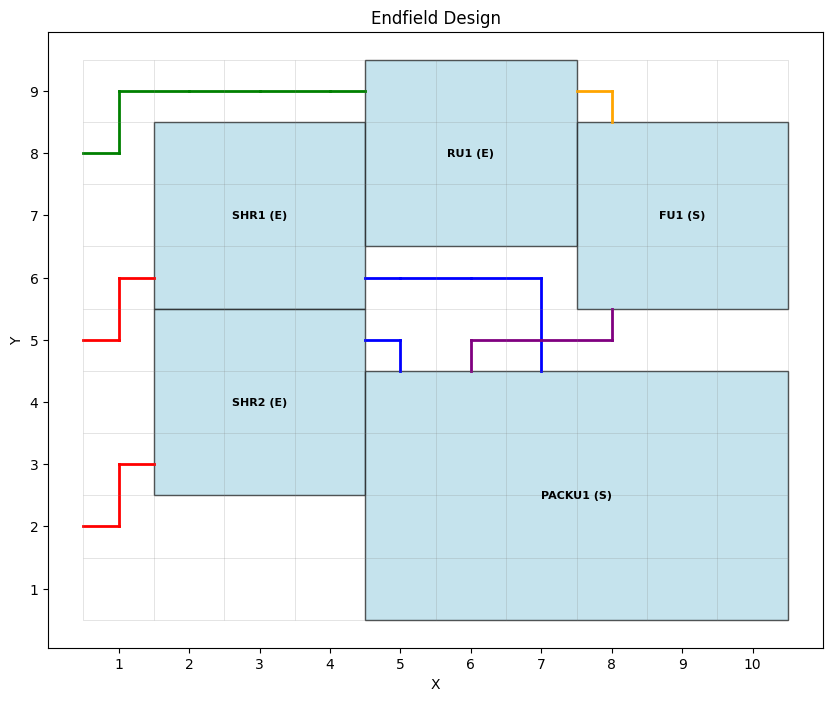

In [2]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

fig, ax = plt.subplots(figsize=(10, 8))
colors = ["red", "blue", "green", "orange", "purple", "brown", "pink", "gray"]

# Buildings
for name, x, y, w, h, o in zip(
    BUILDING_NAMES,
    data.building_x,
    data.building_y,
    data.building_dx,
    data.building_dy,
    data.building_orientation,
):
    rect = patches.Rectangle(
        (x, y), w, h, linewidth=1, edgecolor="black", facecolor="lightblue", alpha=0.7
    )
    ax.add_patch(rect)
    ax.text(
        x + w / 2,
        y + h / 2,
        f"{name} ({o[0]})",
        ha="center",
        va="center",
        fontsize=8,
        weight="bold",
    )

# Conveyors
for i, f in enumerate(flow):
    for path in trace_path(ARCS, f):
        # from where
        c = [*zip(data.conveyor_start_x, data.conveyor_start_y)].index(path[0])
        name = CONVEYORS[c][0]
        ori = (
            data.building_orientation[BUILDING_NAMES.index(name)]
            if name is not None
            else "EAST"
        )
        dx = {"EAST": -0.5, "WEST": 0.5}.get(ori, 0)
        dy = {"NORTH": -0.5, "SOUTH": 0.5}.get(ori, 0)
        x, y = path[0]
        x, y = x + 0.5, y + 0.5
        ax.plot([x, x + dx], [y, y + dy], colors[i % len(colors)], linewidth=2)

        # to where
        ori = data.building_orientation[BUILDING_NAMES.index(CONVEYORS[c][1])]
        dx = {"EAST": 0.5, "WEST": -0.5}.get(ori, 0)
        dy = {"NORTH": 0.5, "SOUTH": -0.5}.get(ori, 0)
        x, y = path[-1]
        x, y = x + 0.5, y + 0.5
        ax.plot([x, x + dx], [y, y + dy], colors[i % len(colors)], linewidth=2)

        for (x1, y1), (x2, y2) in zip(path, path[1:]):
            ax.plot(
                [x1 + 0.5, x2 + 0.5],
                [y1 + 0.5, y2 + 0.5],
                colors[i % len(colors)],
                linewidth=2,
            )

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_title("Endfield Design")
ax.autoscale()

xmax = max(a + b for a, b in zip(data.building_x, data.building_dx))
ymax = max(a + b for a, b in zip(data.building_y, data.building_dy))

x_ticks = [i + 0.5 for i in range(1, xmax)]
x_labels = [i for i in range(1, xmax)]
ax.set_xticks(x_ticks)
ax.set_xticklabels(x_labels)
y_ticks = [i + 0.5 for i in range(1, ymax)]
y_labels = [i for i in range(1, ymax)]
ax.set_yticks(y_ticks)
ax.set_yticklabels(y_labels)
# Grid at integers
ax.vlines(range(1, xmax + 1), 1, ymax, alpha=0.3, color="gray", linewidth=0.5)
ax.hlines(range(1, ymax + 1), 1, xmax, alpha=0.3, color="gray", linewidth=0.5)
plt.show()

In [3]:
flow

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(5, 1231))